In [181]:
# 1) Connect Google Drive

from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [182]:
!pip -q install pandas numpy scikit-learn sentence-transformers joblib matplotlib

In [183]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

import joblib

In [184]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [185]:
DATA_PATH = "/content/drive/MyDrive/answer_quality.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset Loaded Successfully ✅")
print("Shape:", df.shape)
df.head()

Dataset Loaded Successfully ✅
Shape: (264, 5)


,job_role,question_text,reference_answer,student_answer,label
0,Senior Accountant,Explain depreciation.,Depreciation allocates asset cost over useful ...,It allocates asset cost over useful life.,Good
1,Senior Accountant,Explain depreciation.,Depreciation allocates asset cost over useful ...,It reduces asset value each year to reflect we...,Average
2,Senior Accountant,Explain depreciation.,Depreciation allocates asset cost over useful ...,Depreciation is the salary paid to workers.,Poor
3,Senior Accountant,What is accounts payable?,Accounts payable is money the company owes to ...,Accounts payable is money the company owes to ...,Good
4,Senior Accountant,What is accounts payable?,Accounts payable is money the company owes to ...,Accounts payable is the bills the company need...,Average


In [186]:
print("Columns:")
print(df.columns.tolist())

Columns:
['job_role', 'question_text', 'reference_answer', 'student_answer', 'label']


In [187]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264 entries, 0 to 263
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   job_role          264 non-null    object
 1   question_text     264 non-null    object
 2   reference_answer  264 non-null    object
 3   student_answer    264 non-null    object
 4   label             264 non-null    object
dtypes: object(5)
memory usage: 10.4+ KB


In [188]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
job_role            0
question_text       0
reference_answer    0
student_answer      0
label               0
dtype: int64


In [189]:
df["label"].value_counts()

,count
label,
Good,88
Average,88
Poor,88


In [190]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
print("Updated Columns:", df.columns.tolist())

Updated Columns: ['job_role', 'question_text', 'reference_answer', 'student_answer', 'label']


In [191]:
text_columns = ["question_text", "reference_answer", "student_answer"]

for col in text_columns:
    df[col] = df[col].astype(str).str.strip()

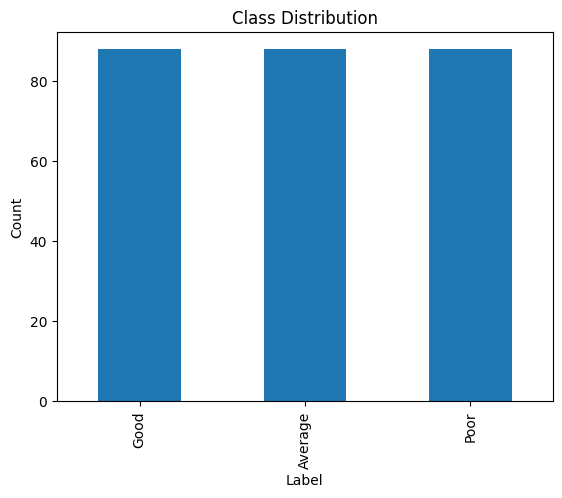

label
Good       88
Average    88
Poor       88
Name: count, dtype: int64


In [192]:
import matplotlib.pyplot as plt

label_counts = df["label"].value_counts()

plt.figure()
label_counts.plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

print(label_counts)

In [193]:
df["answer_length"] = df["student_answer"].apply(lambda x: len(x.split()))
df["reference_length"] = df["reference_answer"].apply(lambda x: len(x.split()))

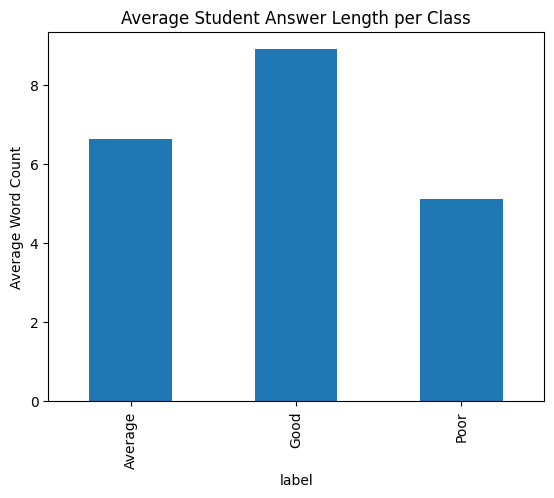

,answer_length
label,
Average,6.636364
Good,8.897727
Poor,5.125000


In [194]:
plt.figure()
df.groupby("label")["answer_length"].mean().plot(kind="bar")
plt.title("Average Student Answer Length per Class")
plt.ylabel("Average Word Count")
plt.show()

df.groupby("label")["answer_length"].mean()

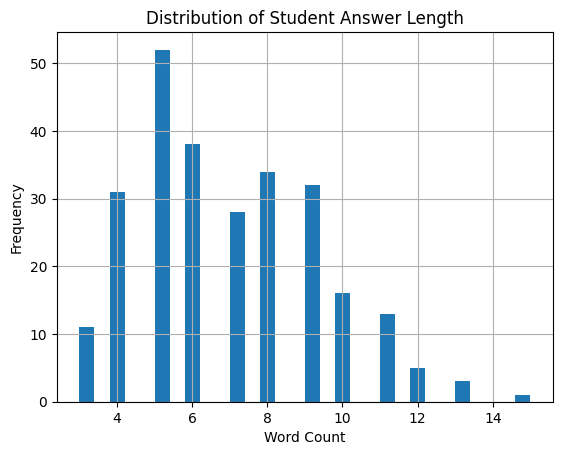

In [195]:
plt.figure()
df["answer_length"].hist(bins=30)
plt.title("Distribution of Student Answer Length")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

In [196]:
df.sample(5)

,job_role,question_text,reference_answer,student_answer,label,answer_length,reference_length
68,HR Generalist,Explain the recruitment process.,"Recruitment involves sourcing, screening, inte...",Recruitment is calculating employee salary.,Poor,5,9
194,Business Development Executive,What is competitive analysis?,Competitive analysis evaluates competitors’ st...,Competitive analysis is hiring employees.,Poor,5,11
82,HR Generalist,What is attrition?,Attrition is the rate at which employees leave...,Attrition means employees leaving the company.,Average,6,15
247,Junior BPO Executive,What is service level agreement (SLA)?,An SLA defines the expected service performanc...,SLA is service agreement.,Average,4,12
109,HR Generalist,How do you measure employee satisfaction?,"Through surveys, feedback sessions, performanc...",Ask employees if they are happy.,Average,6,9


In [197]:
print("Unique labels (raw):", df["label"].unique()[:20])

Unique labels (raw): ['Good' 'Average' 'Poor']


In [198]:
label_map = {
    "Poor": 0,
    "Average": 1,
    "Good": 2
}

df["label_encoded"] = df["label"].map(label_map)

print(df[["label", "label_encoded"]].head())

     label  label_encoded
0     Good              2
1  Average              1
2     Poor              0
3     Good              2
4  Average              1


In [199]:
df["label_encoded"].value_counts()

,count
label_encoded,
2,88
1,88
0,88


In [200]:
y = df["label_encoded"].values

In [201]:
df["combined_text"] = (
    "Question: " + df["question_text"] +
    " Reference Answer: " + df["reference_answer"] +
    " Student Answer: " + df["student_answer"]
)

df["combined_text"].iloc[0]

'Question: Explain depreciation. Reference Answer: Depreciation allocates asset cost over useful life. Student Answer: It allocates asset cost over useful life.'

In [202]:
df["length_difference"] = (
    df["student_answer"].apply(lambda x: len(x.split())) -
    df["reference_answer"].apply(lambda x: len(x.split()))
)

In [203]:
df[["answer_length", "reference_length", "length_difference"]].head()

,answer_length,reference_length,length_difference
0,7,7,0
1,11,7,4
2,7,7,0
3,9,9,0
4,11,9,2


In [204]:
texts = df["combined_text"].tolist()

In [205]:
embedder = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [206]:
X_embed = embedder.encode(
    texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("Embedding Shape:", X_embed.shape)

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Embedding Shape: (264, 384)


In [207]:
ref_emb = embedder.encode(
    df["reference_answer"].tolist(),
    batch_size=64,
    convert_to_numpy=True,
    normalize_embeddings=True
)

stud_emb = embedder.encode(
    df["student_answer"].tolist(),
    batch_size=64,
    convert_to_numpy=True,
    normalize_embeddings=True
)

In [208]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(ref_emb, stud_emb).diagonal()

similarity = similarity.reshape(-1, 1)

print("Similarity Shape:", similarity.shape)

Similarity Shape: (264, 1)


In [209]:
length_feature = df["length_difference"].values.reshape(-1, 1)

In [210]:
import numpy as np

X = np.hstack([X_embed, similarity, length_feature])

print("Final Feature Matrix Shape:", X.shape)

Final Feature Matrix Shape: (264, 386)


In [211]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (211, 386)  Test: (53, 386)


In [234]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

base = RandomForestClassifier(
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

param_dist = {
    "n_estimators": randint(400, 1800),
    "max_depth": randint(8, 28),
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 10),
    "max_features": uniform(0.15, 0.55)  # 0.15..0.70
}

search = RandomizedSearchCV(
    base,
    param_distributions=param_dist,
    n_iter=25,
    scoring="f1_macro",
    cv=5,
    verbose=1,
    random_state=RANDOM_STATE
)

search.fit(X_train, y_train)
rf = search.best_estimator_
print("Best params:", search.best_params_)
print("Best CV f1_macro:", search.best_score_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best params: {'max_depth': 16, 'max_features': np.float64(0.6532278215490794), 'min_samples_leaf': 9, 'min_samples_split': 9, 'n_estimators': 1179}
Best CV f1_macro: 0.5423158114462405


In [235]:
rf.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [236]:
from sklearn.metrics import accuracy_score

train_pred = rf.predict(X_train)
test_pred = rf.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy :", accuracy_score(y_test, test_pred))

Train Accuracy: 0.8957345971563981
Test Accuracy : 0.5283018867924528


In [237]:
from sklearn.metrics import accuracy_score

y_pred = rf.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.5283018867924528


In [238]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=["Poor", "Average", "Good"]))

              precision    recall  f1-score   support

        Poor       0.47      0.53      0.50        17
     Average       0.36      0.22      0.28        18
        Good       0.65      0.83      0.73        18

    accuracy                           0.53        53
   macro avg       0.50      0.53      0.50        53
weighted avg       0.50      0.53      0.50        53



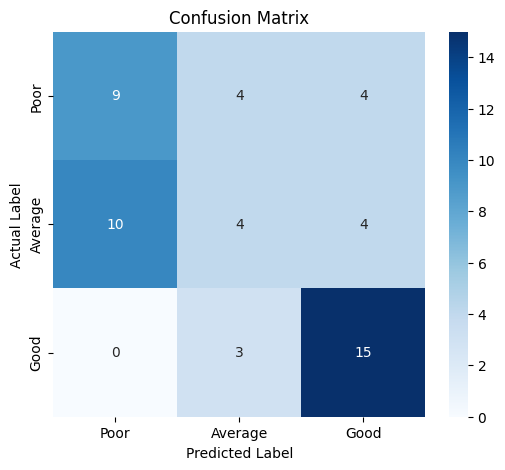

In [239]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

labels = ["Poor", "Average", "Good"]

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()

In [240]:
misclassified = X_test[y_test != y_pred]
print("Total mistakes:", len(misclassified))

Total mistakes: 25


In [241]:
from sklearn.metrics import f1_score

macro_f1 = f1_score(y_test, y_pred, average="macro")
print("Macro F1 Score:", macro_f1)

Macro F1 Score: 0.5025231286795626


In [256]:
# ✅ Use the best estimator found by RandomizedSearchCV
best_rf = search.best_estimator_

# ✅ Keep label_map consistent (pick ONE style — I recommend lowercase)
artifact_tuned = {
    "model": best_rf,
    "label_map": {"Poor": 0, "Average": 1, "Good": 2},
    "embedder_name": "all-MiniLM-L6-v2",
    "features": ["combined_embedding", "cosine_similarity", "length_difference"],
    "best_cv_macro_f1": float(search.best_score_),
    "best_params": search.best_params_
}

joblib.dump(artifact_tuned, "answer_quality_rf_TUNED.joblib")
print("Saved -> answer_quality_rf_TUNED.joblib")

Saved -> answer_quality_rf_TUNED.joblib


In [257]:
embedder.save("embedder_all_MiniLM_L6_v2")
print("Saved embedder folder -> embedder_all_MiniLM_L6_v2")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved embedder folder -> embedder_all_MiniLM_L6_v2


In [258]:
loaded = joblib.load("answer_quality_rf_TUNED.joblib")

rf_loaded = loaded["model"]
label_map = loaded["label_map"]
inv_label_map = {v: k for k, v in label_map.items()}

embedder_loaded = SentenceTransformer("embedder_all_MiniLM_L6_v2")  # loads from saved folder

def predict_quality(question_text: str, reference_answer: str, student_answer: str):
    # 1) Combined text embedding
    combined = (
        f"Question: {question_text} "
        f"Reference Answer: {reference_answer} "
        f"Student Answer: {student_answer}"
    )
    emb = embedder_loaded.encode([combined], convert_to_numpy=True, normalize_embeddings=True)

    # 2) Cosine similarity (reference vs student)
    ref_e  = embedder_loaded.encode([reference_answer], convert_to_numpy=True, normalize_embeddings=True)
    stud_e = embedder_loaded.encode([student_answer], convert_to_numpy=True, normalize_embeddings=True)
    sim = cosine_similarity(ref_e, stud_e)  # shape (1,1)

    # 3) Length difference
    len_diff = np.array([[len(student_answer.split()) - len(reference_answer.split())]])

    # 4) Final feature vector
    X_new = np.hstack([emb, sim, len_diff])

    # 5) Predict
    pred_class = int(rf_loaded.predict(X_new)[0])
    probs = rf_loaded.predict_proba(X_new)[0]  # order = [0,1,2]

    return {
        "prediction": inv_label_map[pred_class],
        "prob_poor": float(probs[0]),
        "prob_average": float(probs[1]),
        "prob_good": float(probs[2]),
        "similarity": float(sim[0, 0]),
        "length_diff": int(len_diff[0, 0])
    }

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [259]:
predict_quality(
    "What is the capital of France?",
    "Paris",
    "The capital of France is Paris."
)

{'prediction': 'Good',
 'prob_poor': 0.06123156630742695,
 'prob_average': 0.19148567979881756,
 'prob_good': 0.7472827538937568,
 'similarity': 0.725335955619812,
 'length_diff': 5}

In [260]:
# Use the same embedder_loaded you already have
from sklearn.metrics.pairwise import cosine_similarity

q = "What is the capital of France?"
ref_short = "Paris"
ref_long  = "The capital of France is Paris."
stu = "The capital of France is Paris."

ref_short_e = embedder_loaded.encode([ref_short], normalize_embeddings=True)
ref_long_e  = embedder_loaded.encode([ref_long],  normalize_embeddings=True)
stu_e       = embedder_loaded.encode([stu],       normalize_embeddings=True)

sim_short = float(cosine_similarity(ref_short_e, stu_e)[0,0])
sim_long  = float(cosine_similarity(ref_long_e,  stu_e)[0,0])

print("Similarity (short ref):", sim_short)
print("Similarity (long  ref):", sim_long)

Similarity (short ref): 0.725335955619812
Similarity (long  ref): 1.0000001192092896


In [261]:
print("Pred with SHORT reference:")
print(predict_quality(q, ref_short, stu))

Pred with SHORT reference:
{'prediction': 'Good', 'prob_poor': 0.06123156630742695, 'prob_average': 0.19148567979881756, 'prob_good': 0.7472827538937568, 'similarity': 0.725335955619812, 'length_diff': 5}


In [262]:
q_e   = embedder_loaded.encode([q],   normalize_embeddings=True)
stu_e = embedder_loaded.encode([stu], normalize_embeddings=True)

sim_qs = float(cosine_similarity(q_e, stu_e)[0,0])
print("Question↔Student similarity:", sim_qs)

Question↔Student similarity: 0.8790109157562256


In [263]:
def predict_quality_with_rule(question, reference, student):
    out = predict_quality(question, reference, student)

    # Simple post-rule (tweak these thresholds later)
    if out["similarity"] >= 0.80:
        out["prediction_rule"] = "good"
    elif out["similarity"] <= 0.45:
        out["prediction_rule"] = "poor"
    else:
        out["prediction_rule"] = out["prediction"]

    return out

print(predict_quality_with_rule(q, ref_short, stu))

{'prediction': 'Good', 'prob_poor': 0.06123156630742695, 'prob_average': 0.19148567979881756, 'prob_good': 0.7472827538937568, 'similarity': 0.725335955619812, 'length_diff': 5, 'prediction_rule': 'Good'}
